In [1]:
import pandas as pd
import re

real = pd.read_csv("D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv")
fake = pd.read_csv("D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv")

real["type"] = "real"
fake["type"] = "fake"

df = pd.concat([real, fake], ignore_index=True)

# keep only actual feature columns: f000, f001, ..., f127
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

X = df[feature_cols].values
y = df["type"].values

C:\Users\hp\AppData\Local\Temp\ipykernel_10736\3150500231.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  real["type"] = "real"
C:\Users\hp\AppData\Local\Temp\ipykernel_10736\3150500231.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fake["type"] = "fake"


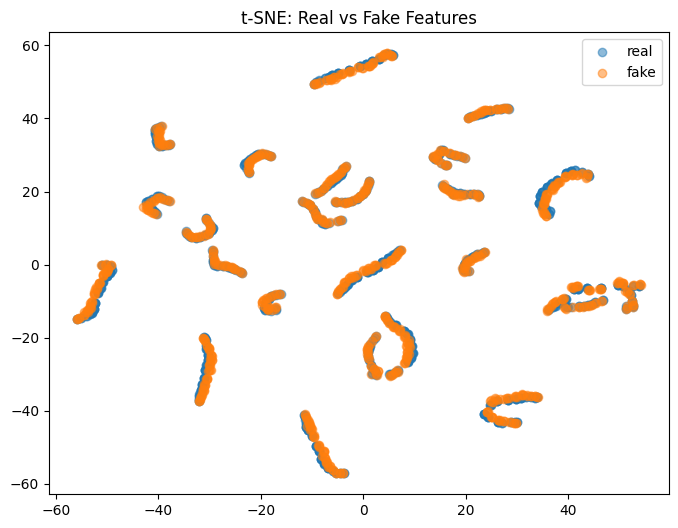

In [2]:
# tsne

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8,6))

for label in ["real", "fake"]:
    idx = (y == label)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, alpha=0.5)

plt.title("t-SNE: Real vs Fake Features")
plt.legend()
plt.show()

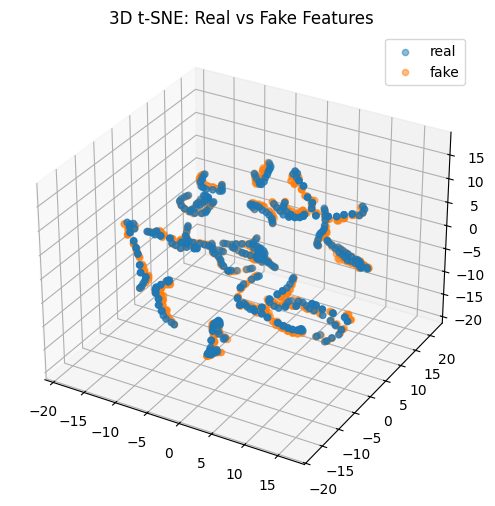

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

tsne = TSNE(n_components=3, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for label in ["real", "fake"]:
    idx = (y == label)
    ax.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        X_tsne[idx, 2],
        label=label,
        alpha=0.5
    )

ax.set_title("3D t-SNE: Real vs Fake Features")
ax.legend()
plt.show()

In [7]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

In [8]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=5, perplexity=30, random_state=42, method="exact")
X_tsne = tsne.fit_transform(X)

print(X_tsne.shape)   # should be (num_samples, 5)

(1584, 5)


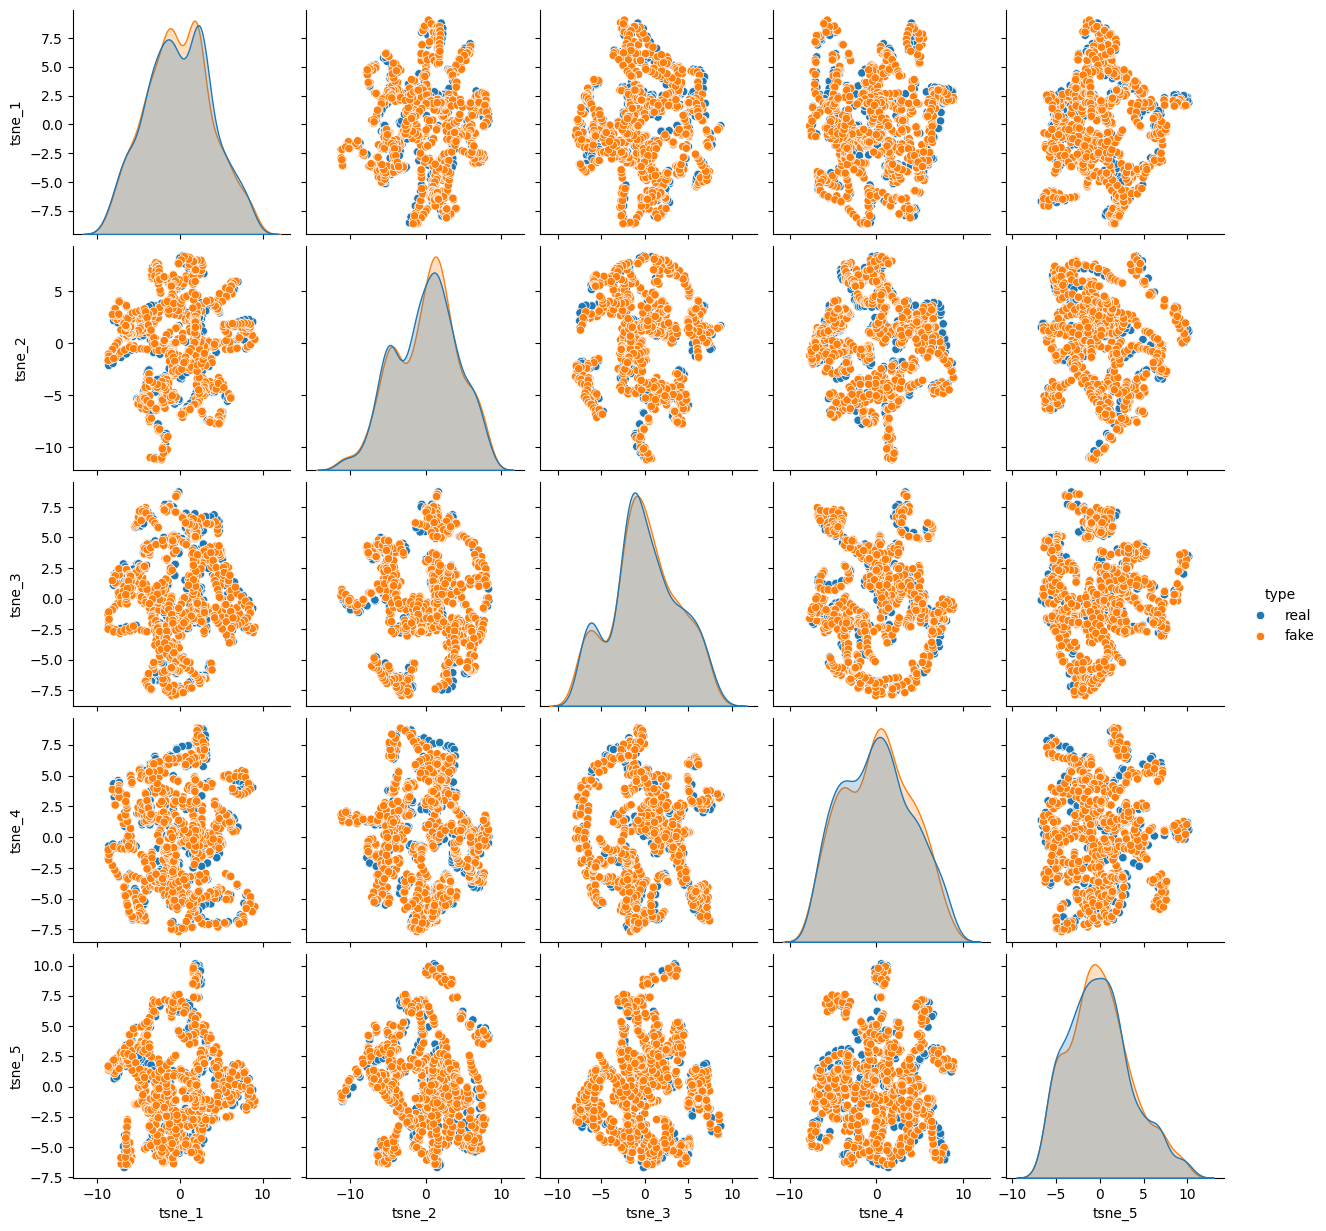

In [9]:
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tsne = TSNE(n_components=5, perplexity=30, random_state=42, method="exact")
X_tsne = tsne.fit_transform(X)

df_tsne = pd.DataFrame(X_tsne, columns=[f"tsne_{i+1}" for i in range(5)])
df_tsne["type"] = y

sns.pairplot(df_tsne, hue="type")
plt.show()

In [26]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# -----------------------------
# Use ORIGINAL features (recommended)
# or you can use X_tsne / X_umap
# -----------------------------
X_data = X   # <-- best: original feature space

# Fit kNN
k = 10
nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_data)
distances, indices = nbrs.kneighbors(X_data)

# remove self neighbor (first column)
indices = indices[:, 1:]

# -----------------------------
# Compute overlap
# -----------------------------
fake_idx = np.where(y == "fake")[0]

real_counts = []
fake_counts = []

for i in fake_idx:
    neighbor_labels = y[indices[i]]
    
    real_count = np.sum(neighbor_labels == "real")
    fake_count = np.sum(neighbor_labels == "fake")
    
    real_counts.append(real_count)
    fake_counts.append(fake_count)

real_counts = np.array(real_counts)
fake_counts = np.array(fake_counts)

# -----------------------------
# Results
# -----------------------------
print("Average real neighbors:", real_counts.mean())
print("Average fake neighbors:", fake_counts.mean())

print("Fraction of real neighbors:", real_counts.mean() / k)

Average real neighbors: 4.845959595959596
Average fake neighbors: 5.154040404040404
Fraction of real neighbors: 0.4845959595959596


In [27]:
mixing_score = real_counts.mean() / k
print("Mixing Score:", mixing_score)

Mixing Score: 0.4845959595959596


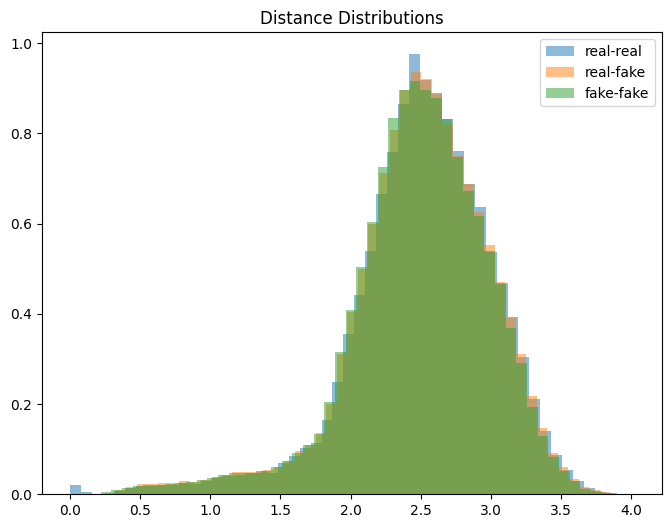

In [28]:
import numpy as np
from sklearn.metrics import pairwise_distances

# split data
X_real = X[y == "real"]
X_fake = X[y == "fake"]

# -----------------------------
# Compute distances
# -----------------------------
# real-real
dist_rr = pairwise_distances(X_real, X_real)
dist_rr = dist_rr[np.triu_indices_from(dist_rr, k=1)]

# real-fake
dist_rf = pairwise_distances(X_real, X_fake).flatten()

# fake-fake (optional)
dist_ff = pairwise_distances(X_fake, X_fake)
dist_ff = dist_ff[np.triu_indices_from(dist_ff, k=1)]

# -----------------------------
# Plot distributions
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(dist_rr, bins=50, alpha=0.5, label="real-real", density=True)
plt.hist(dist_rf, bins=50, alpha=0.5, label="real-fake", density=True)
plt.hist(dist_ff, bins=50, alpha=0.5, label="fake-fake", density=True)

plt.title("Distance Distributions")
plt.legend()
plt.show()

In [21]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from itertools import combinations

# -----------------------------
# Load data
# -----------------------------
real = pd.read_csv("D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv")
fake = pd.read_csv("D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv")

real["type"] = "real"
fake["type"] = "fake"

df = pd.concat([real, fake], ignore_index=True)

# keep only actual feature columns
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

X = df[feature_cols].values
y = df["type"].values

# -----------------------------
# 16D t-SNE
# -----------------------------
tsne = TSNE(
    n_components=16,
    perplexity=30,
    random_state=42,
    method="exact",
    init="pca"
)
X_tsne = tsne.fit_transform(X)

# make dataframe
tsne_cols = [f"d{i+1}" for i in range(16)]
df_tsne = pd.DataFrame(X_tsne, columns=tsne_cols)
df_tsne["type"] = y

print(df_tsne.head())
print("Shape:", df_tsne.shape)

C:\Users\hp\AppData\Local\Temp\ipykernel_10736\3543189580.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  real["type"] = "real"
C:\Users\hp\AppData\Local\Temp\ipykernel_10736\3543189580.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fake["type"] = "fake"


         d1        d2        d3        d4        d5        d6        d7  \
0  3.030042  0.133512 -1.517150 -1.276455  0.407416 -0.441139  0.646261   
1  3.289875  0.215978 -1.453834 -1.128574  0.501786 -0.321004  0.654303   
2  3.977090  0.382148 -1.305100 -0.784403  0.739635 -0.056425  0.698339   
3  4.993522  0.885016 -1.106168 -0.333132  1.248392  0.509750  0.073586   
4  5.023279  0.963710 -0.930779 -0.395788  1.238850  0.626083 -0.024533   

         d8        d9       d10       d11       d12       d13       d14  \
0 -0.101474  0.396027 -0.603463  1.005551  0.077019  0.037405  0.062836   
1 -0.064106  0.275007 -0.524889  0.844988  0.045085  0.064800  0.032635   
2  0.043135 -0.037149 -0.319757  0.389478 -0.052026  0.134487 -0.036577   
3  0.132040 -0.728071  0.078826  0.167514 -0.117792  0.215934 -0.257764   
4  0.144563 -0.987299  0.111139  0.153120 -0.124904  0.215961 -0.293805   

        d15       d16  type  
0  0.561019  0.143256  real  
1  0.513356  0.151929  real  
2  0.373

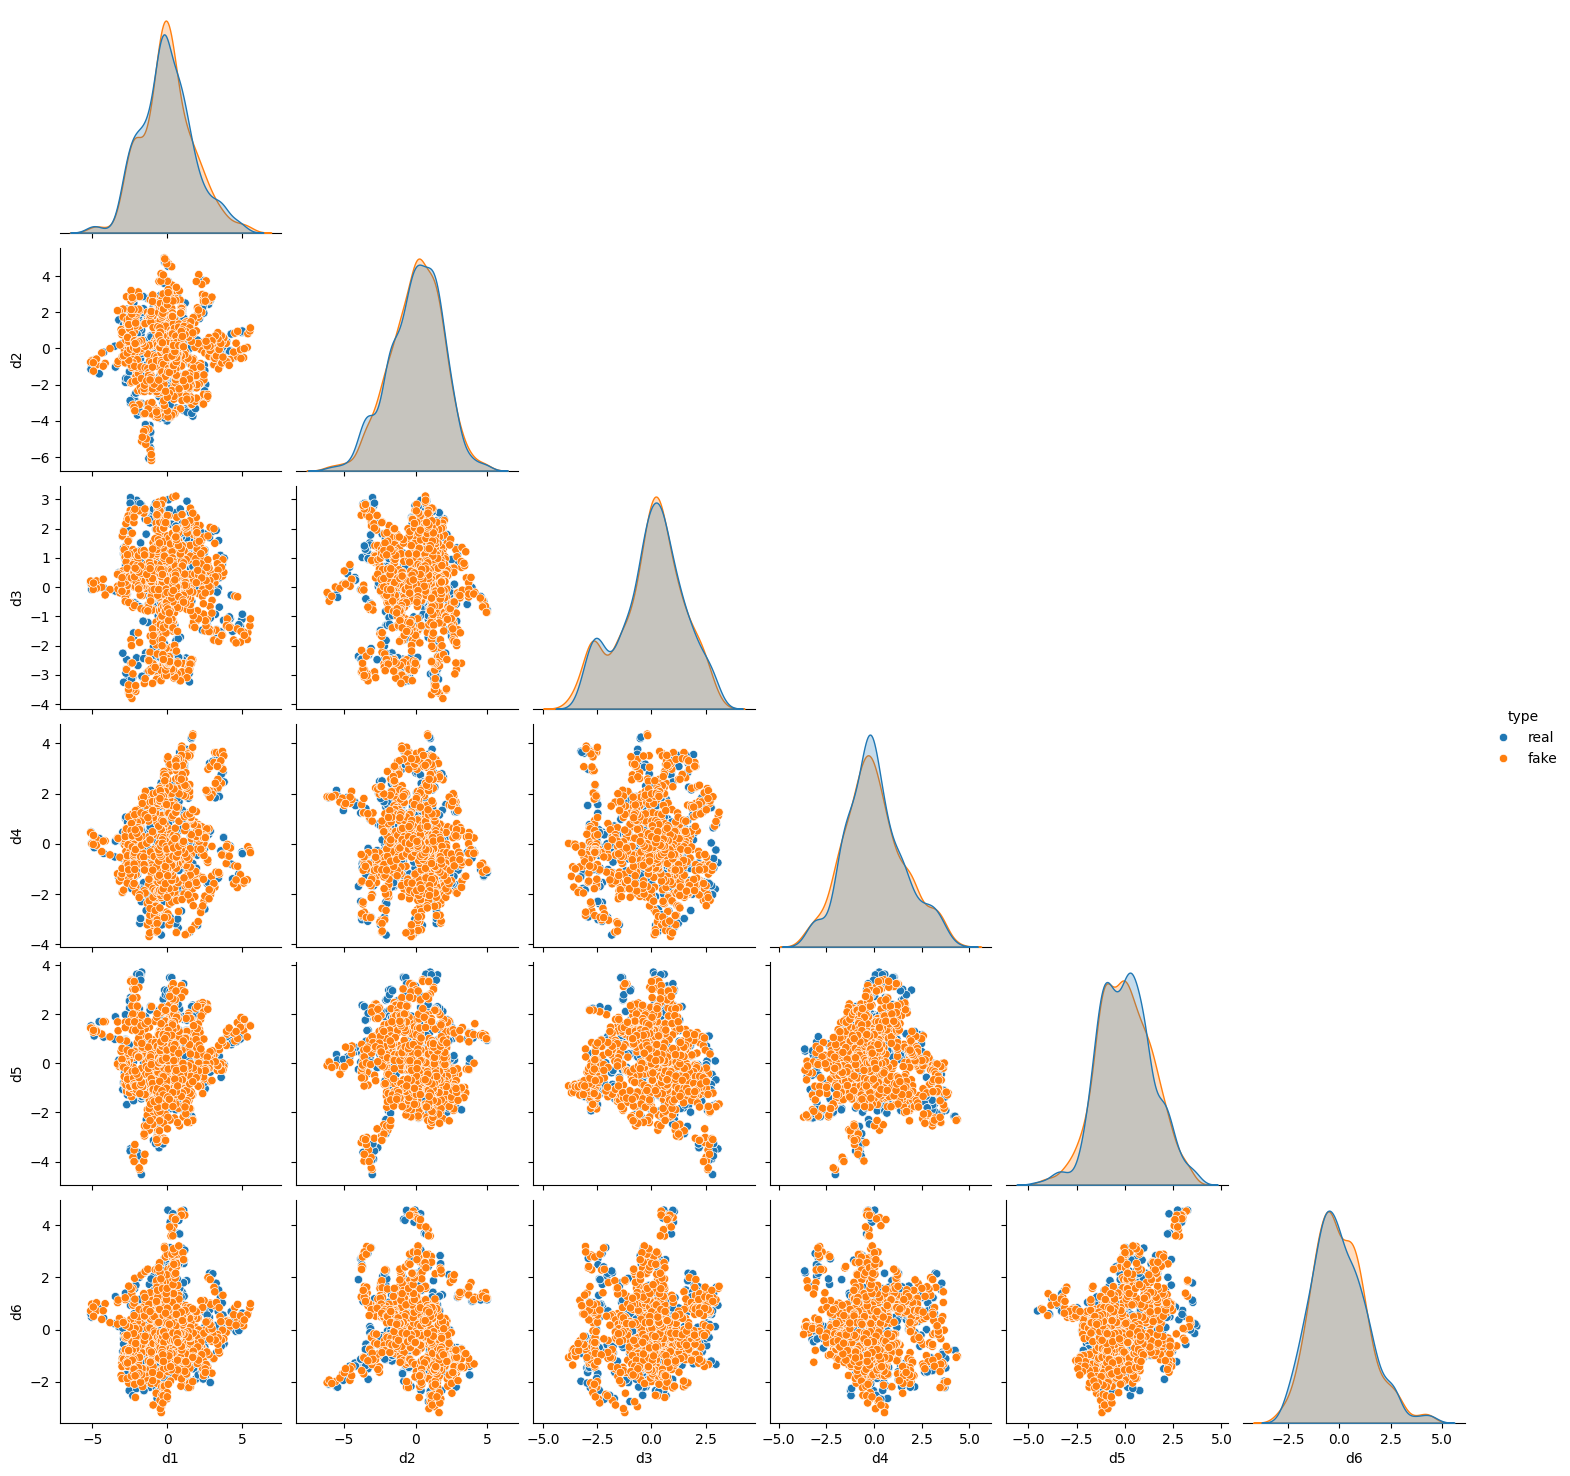

In [22]:
import seaborn as sns

pair_cols = [f"d{i+1}" for i in range(6)]   # first 6 dims only
sns.pairplot(df_tsne[pair_cols + ["type"]], hue="type", corner=True)
plt.show()

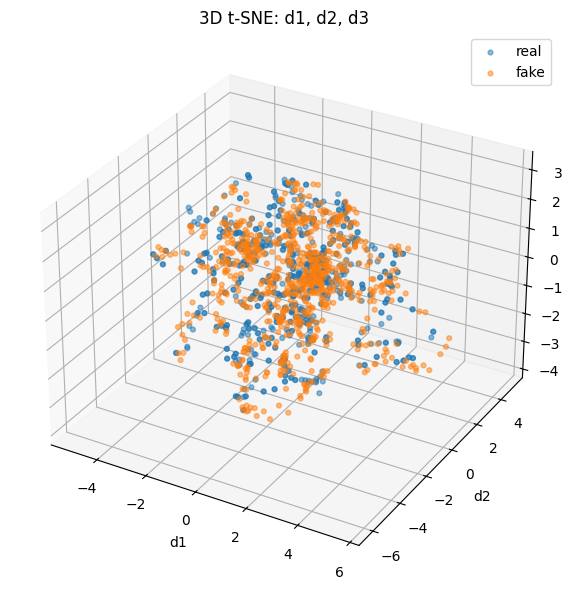

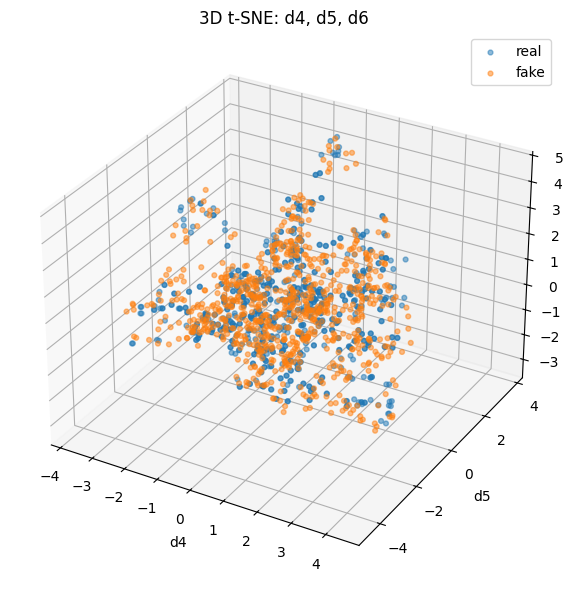

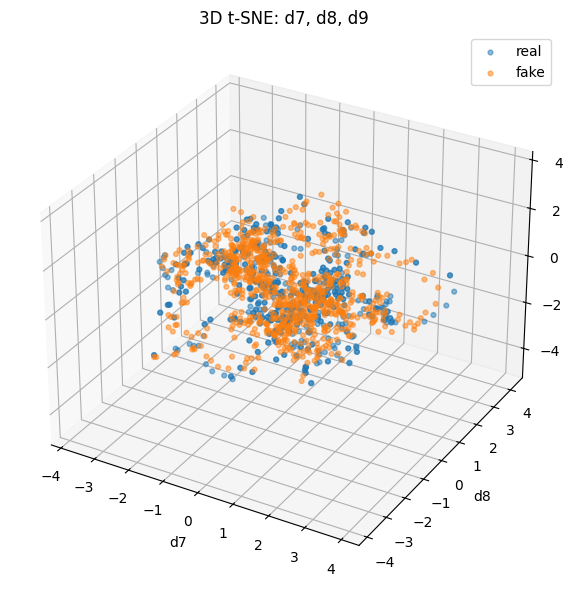

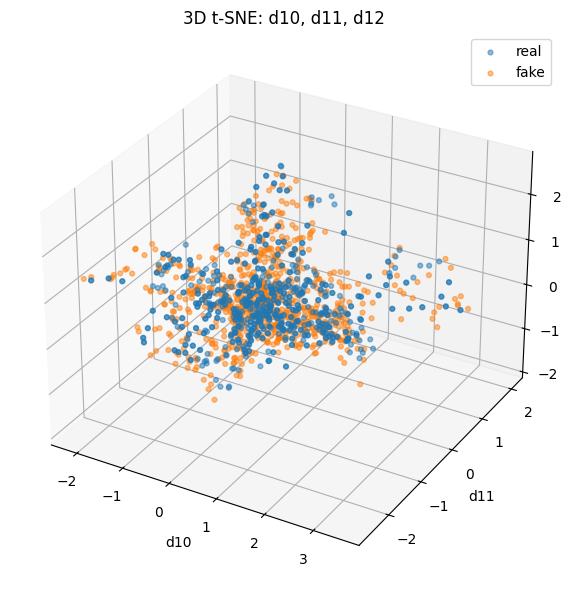

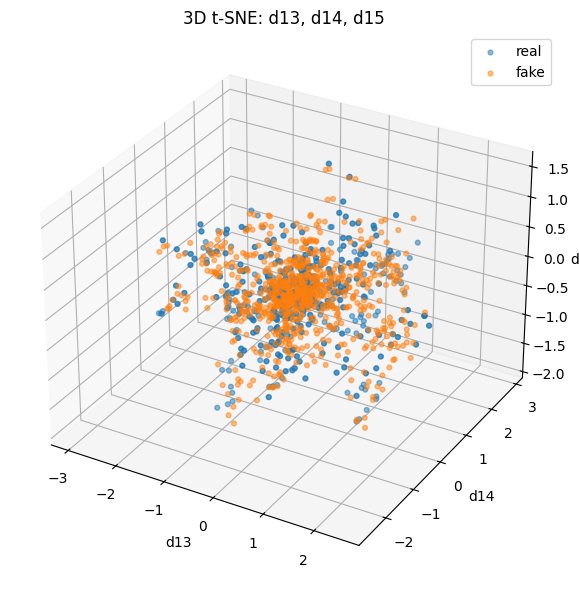

In [23]:
from mpl_toolkits.mplot3d import Axes3D

triples = [
    ("d1", "d2", "d3"),
    ("d4", "d5", "d6"),
    ("d7", "d8", "d9"),
    ("d10", "d11", "d12"),
    ("d13", "d14", "d15"),
]

for xcol, ycol, zcol in triples:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    for label in ["real", "fake"]:
        idx = df_tsne["type"] == label
        ax.scatter(
            df_tsne.loc[idx, xcol],
            df_tsne.loc[idx, ycol],
            df_tsne.loc[idx, zcol],
            label=label,
            alpha=0.5,
            s=12
        )

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_zlabel(zcol)
    ax.set_title(f"3D t-SNE: {xcol}, {ycol}, {zcol}")
    ax.legend()
    plt.tight_layout()
    plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_10736\3858918729.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  real["type"] = "real"
C:\Users\hp\AppData\Local\Temp\ipykernel_10736\3858918729.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fake["type"] = "fake"


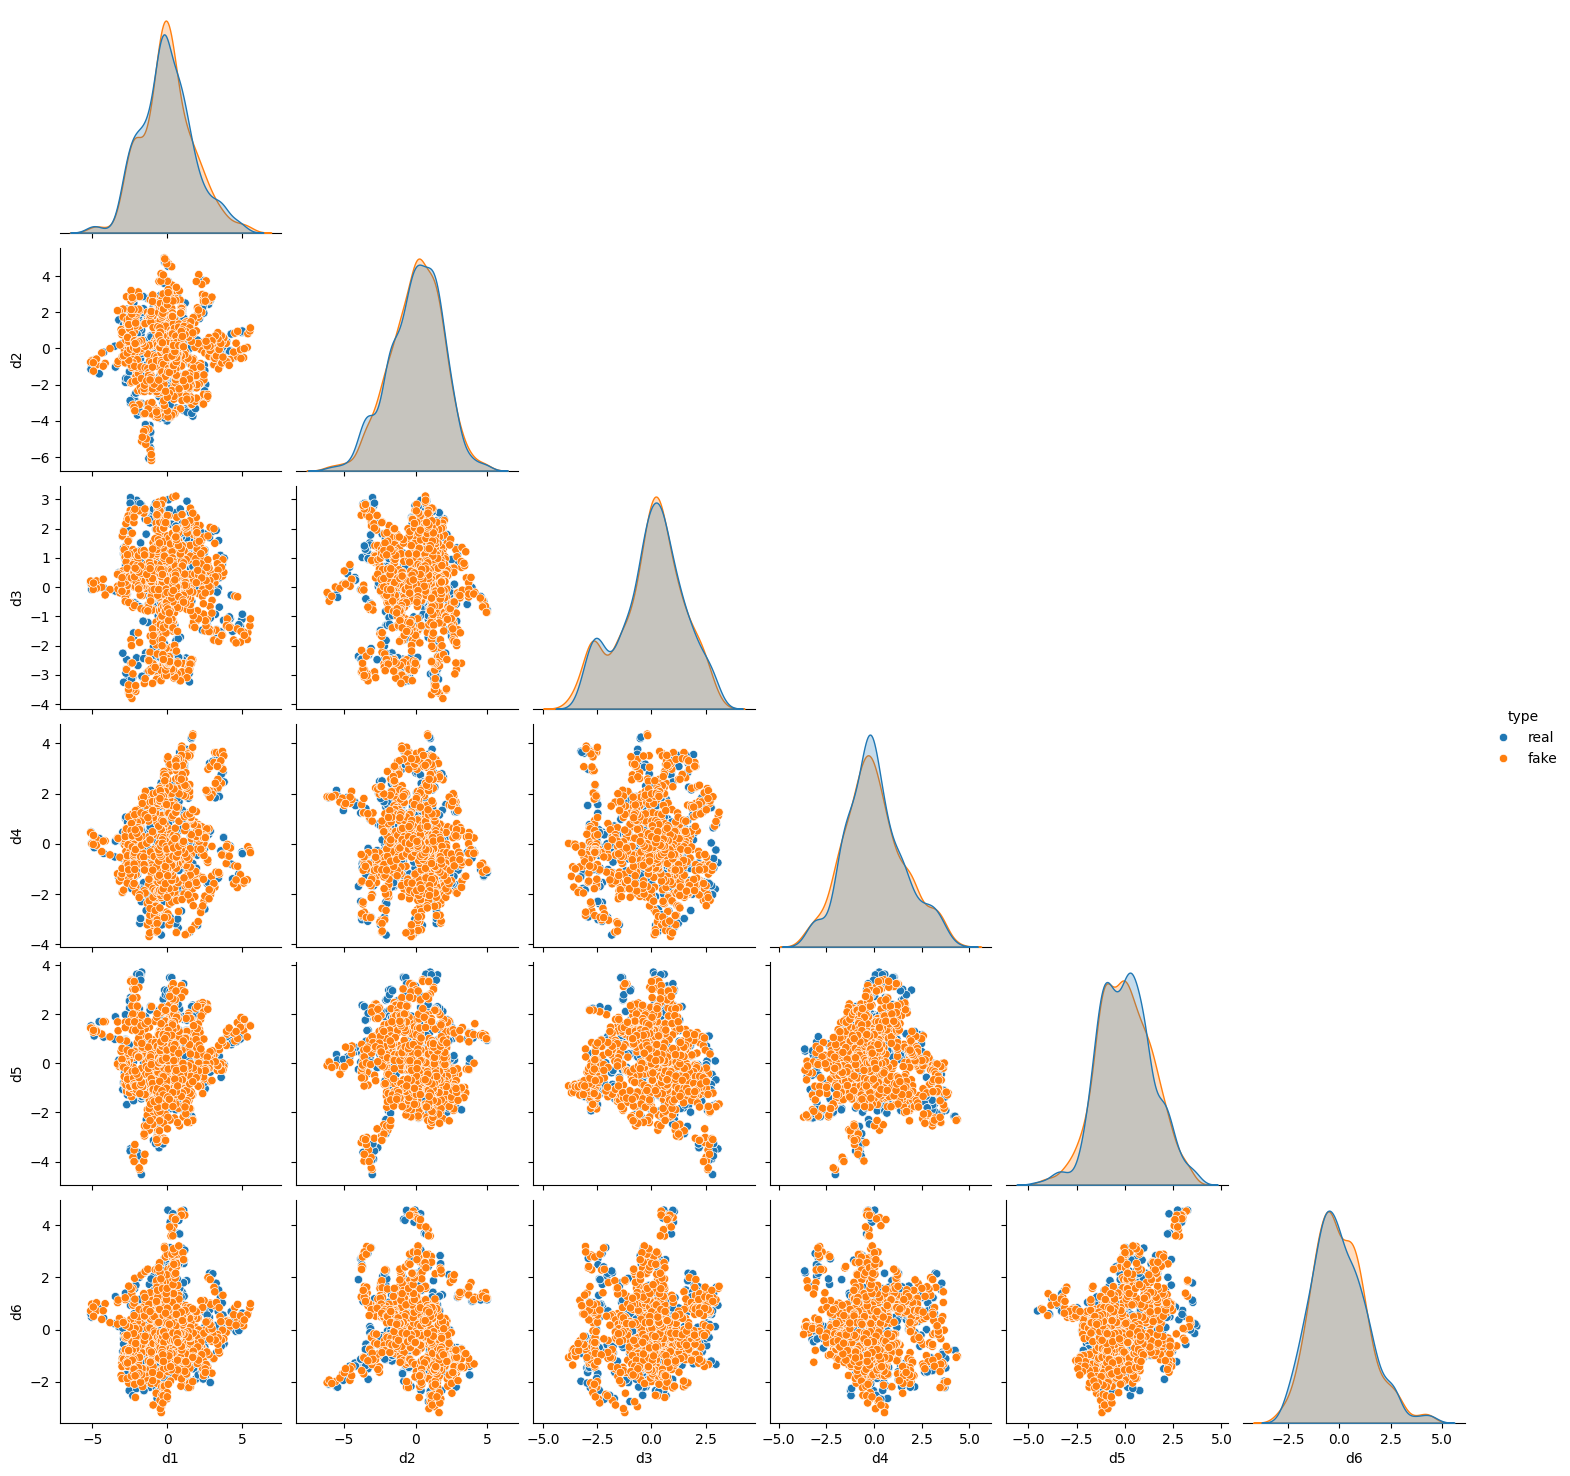

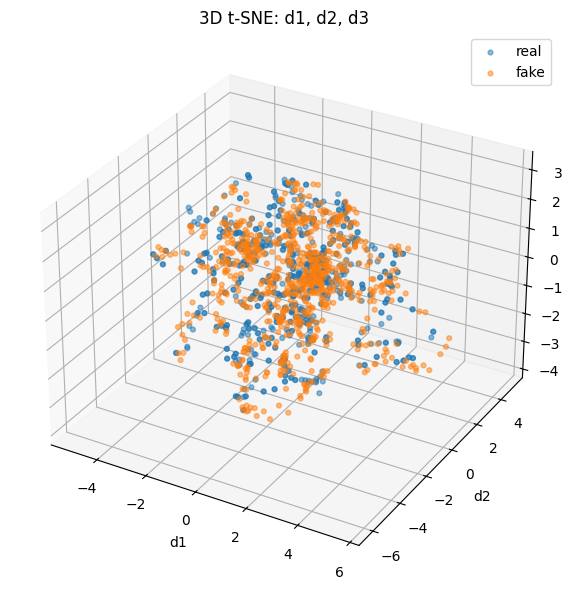

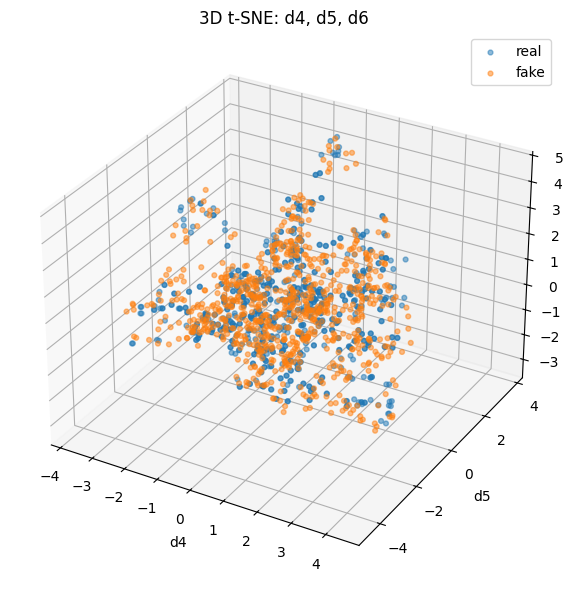

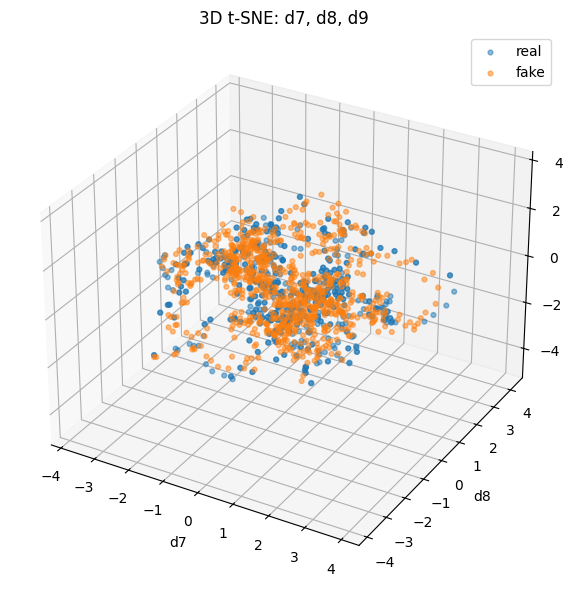

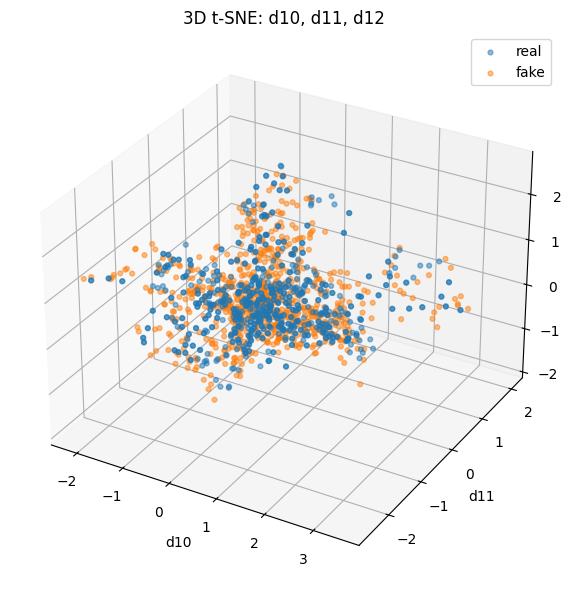

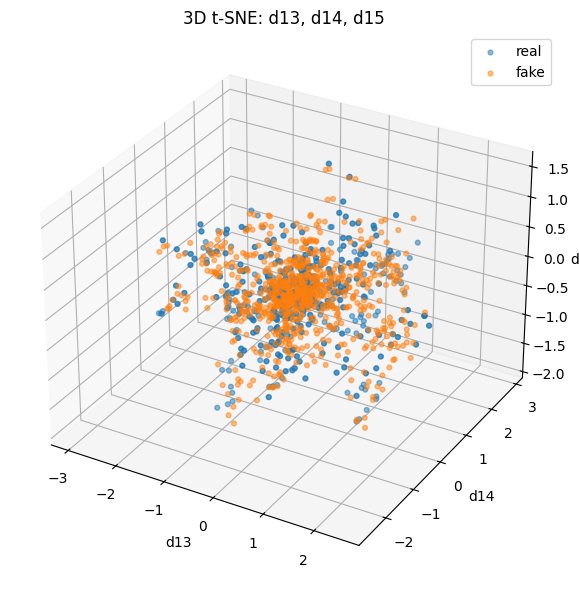

In [24]:
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Load data
# -----------------------------
real = pd.read_csv("D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv")
fake = pd.read_csv("D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv")

real["type"] = "real"
fake["type"] = "fake"

df = pd.concat([real, fake], ignore_index=True)

# optional sampling for speed
sample_n = 2000
if len(df) > sample_n:
    df = df.sample(n=sample_n, random_state=42).reset_index(drop=True)

feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]
X = df[feature_cols].values
y = df["type"].values

# -----------------------------
# 16D t-SNE
# -----------------------------
tsne = TSNE(
    n_components=16,
    perplexity=30,
    random_state=42,
    method="exact",
    init="pca"
)
X_tsne = tsne.fit_transform(X)

tsne_cols = [f"d{i+1}" for i in range(16)]
df_tsne = pd.DataFrame(X_tsne, columns=tsne_cols)
df_tsne["type"] = y

# -----------------------------
# Pairplot for first 6 dims
# -----------------------------
pair_cols = [f"d{i+1}" for i in range(6)]
sns.pairplot(df_tsne[pair_cols + ["type"]], hue="type", corner=True)
plt.show()

# -----------------------------
# 3D grouped plots
# -----------------------------
triples = [
    ("d1", "d2", "d3"),
    ("d4", "d5", "d6"),
    ("d7", "d8", "d9"),
    ("d10", "d11", "d12"),
    ("d13", "d14", "d15"),
]

for xcol, ycol, zcol in triples:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    for label in ["real", "fake"]:
        idx = df_tsne["type"] == label
        ax.scatter(
            df_tsne.loc[idx, xcol],
            df_tsne.loc[idx, ycol],
            df_tsne.loc[idx, zcol],
            alpha=0.5,
            label=label,
            s=12
        )

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_zlabel(zcol)
    ax.set_title(f"3D t-SNE: {xcol}, {ycol}, {zcol}")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [25]:
import os

out_dir = "D:/KLAUS/Vis_Final_Project/tsne_pairwise_16d"
os.makedirs(out_dir, exist_ok=True)

pairs = list(combinations(tsne_cols, 2))

for c1, c2 in pairs:
    plt.figure(figsize=(6, 5))
    
    for label in ["real", "fake"]:
        idx = df_tsne["type"] == label
        plt.scatter(
            df_tsne.loc[idx, c1],
            df_tsne.loc[idx, c2],
            alpha=0.5,
            label=label,
            s=12
        )
    
    plt.xlabel(c1)
    plt.ylabel(c2)
    plt.title(f"t-SNE Pairwise: {c1} vs {c2}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{c1}_vs_{c2}.png"), dpi=200)
    plt.close()

print(f"Saved all pairwise plots in: {out_dir}")

Saved all pairwise plots in: D:/KLAUS/Vis_Final_Project/tsne_pairwise_16d


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


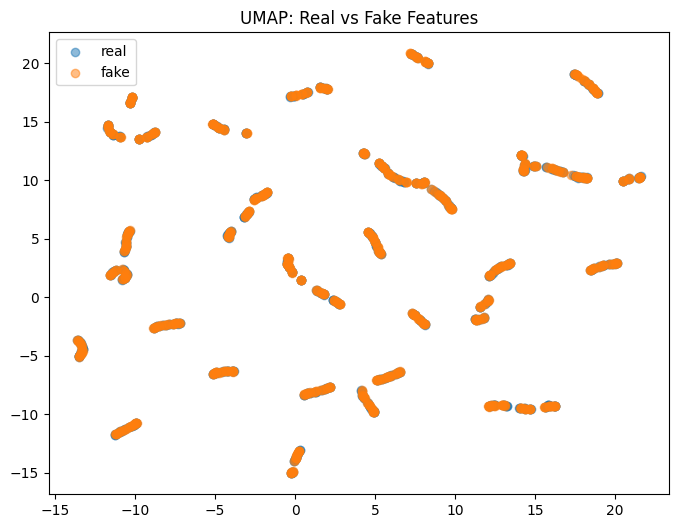

In [14]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X)

plt.figure(figsize=(8,6))

for label in ["real", "fake"]:
    idx = (y == label)
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], label=label, alpha=0.5)

plt.title("UMAP: Real vs Fake Features")
plt.legend()
plt.show()

In [15]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import umap

real = pd.read_csv("D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv")
fake = pd.read_csv("D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv")

real["type"] = "real"
fake["type"] = "fake"

df = pd.concat([real, fake], ignore_index=True)

# keep only actual feature columns: f000, f001, ..., f127
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

X = df[feature_cols].values
y = df["type"].values

# 16D UMAP
reducer = umap.UMAP(
    n_components=16,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X)

C:\Users\hp\AppData\Local\Temp\ipykernel_10736\2059151725.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  real["type"] = "real"
C:\Users\hp\AppData\Local\Temp\ipykernel_10736\2059151725.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fake["type"] = "fake"
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [16]:
import pandas as pd

umap_cols = [f"d{i+1}" for i in range(16)]
df_umap = pd.DataFrame(X_umap, columns=umap_cols)
df_umap["type"] = y

print(df_umap.head())
print(df_umap.shape)

          d1        d2        d3        d4        d5        d6        d7  \
0  15.570107  2.838480  4.660208  6.159336  5.713683  6.159628  5.529575   
1  15.560102  2.825998  4.641968  6.176565  5.695151  6.172960  5.547723   
2  15.583901  2.845562  4.640299  6.129766  5.698277  6.130066  5.520870   
3  15.697599  2.958197  4.648685  5.842143  5.706128  5.842995  5.374904   
4  15.696694  2.966202  4.650051  5.825410  5.714276  5.833563  5.365151   

         d8        d9       d10       d11       d12       d13       d14  \
0  3.980343  2.182212  5.355373  4.048419  5.306011  4.710041  5.556191   
1  3.995732  2.164910  5.339103  4.060574  5.290766  4.692231  5.573584   
2  4.029377  2.197484  5.380430  4.106143  5.281783  4.734588  5.532770   
3  4.273437  2.265173  5.456953  4.432253  5.194406  4.954046  5.482775   
4  4.269072  2.282690  5.476301  4.432825  5.201445  4.971768  5.462345   

        d15       d16  type  
0  5.064105  4.017664  real  
1  5.049529  3.998273  real  
2 

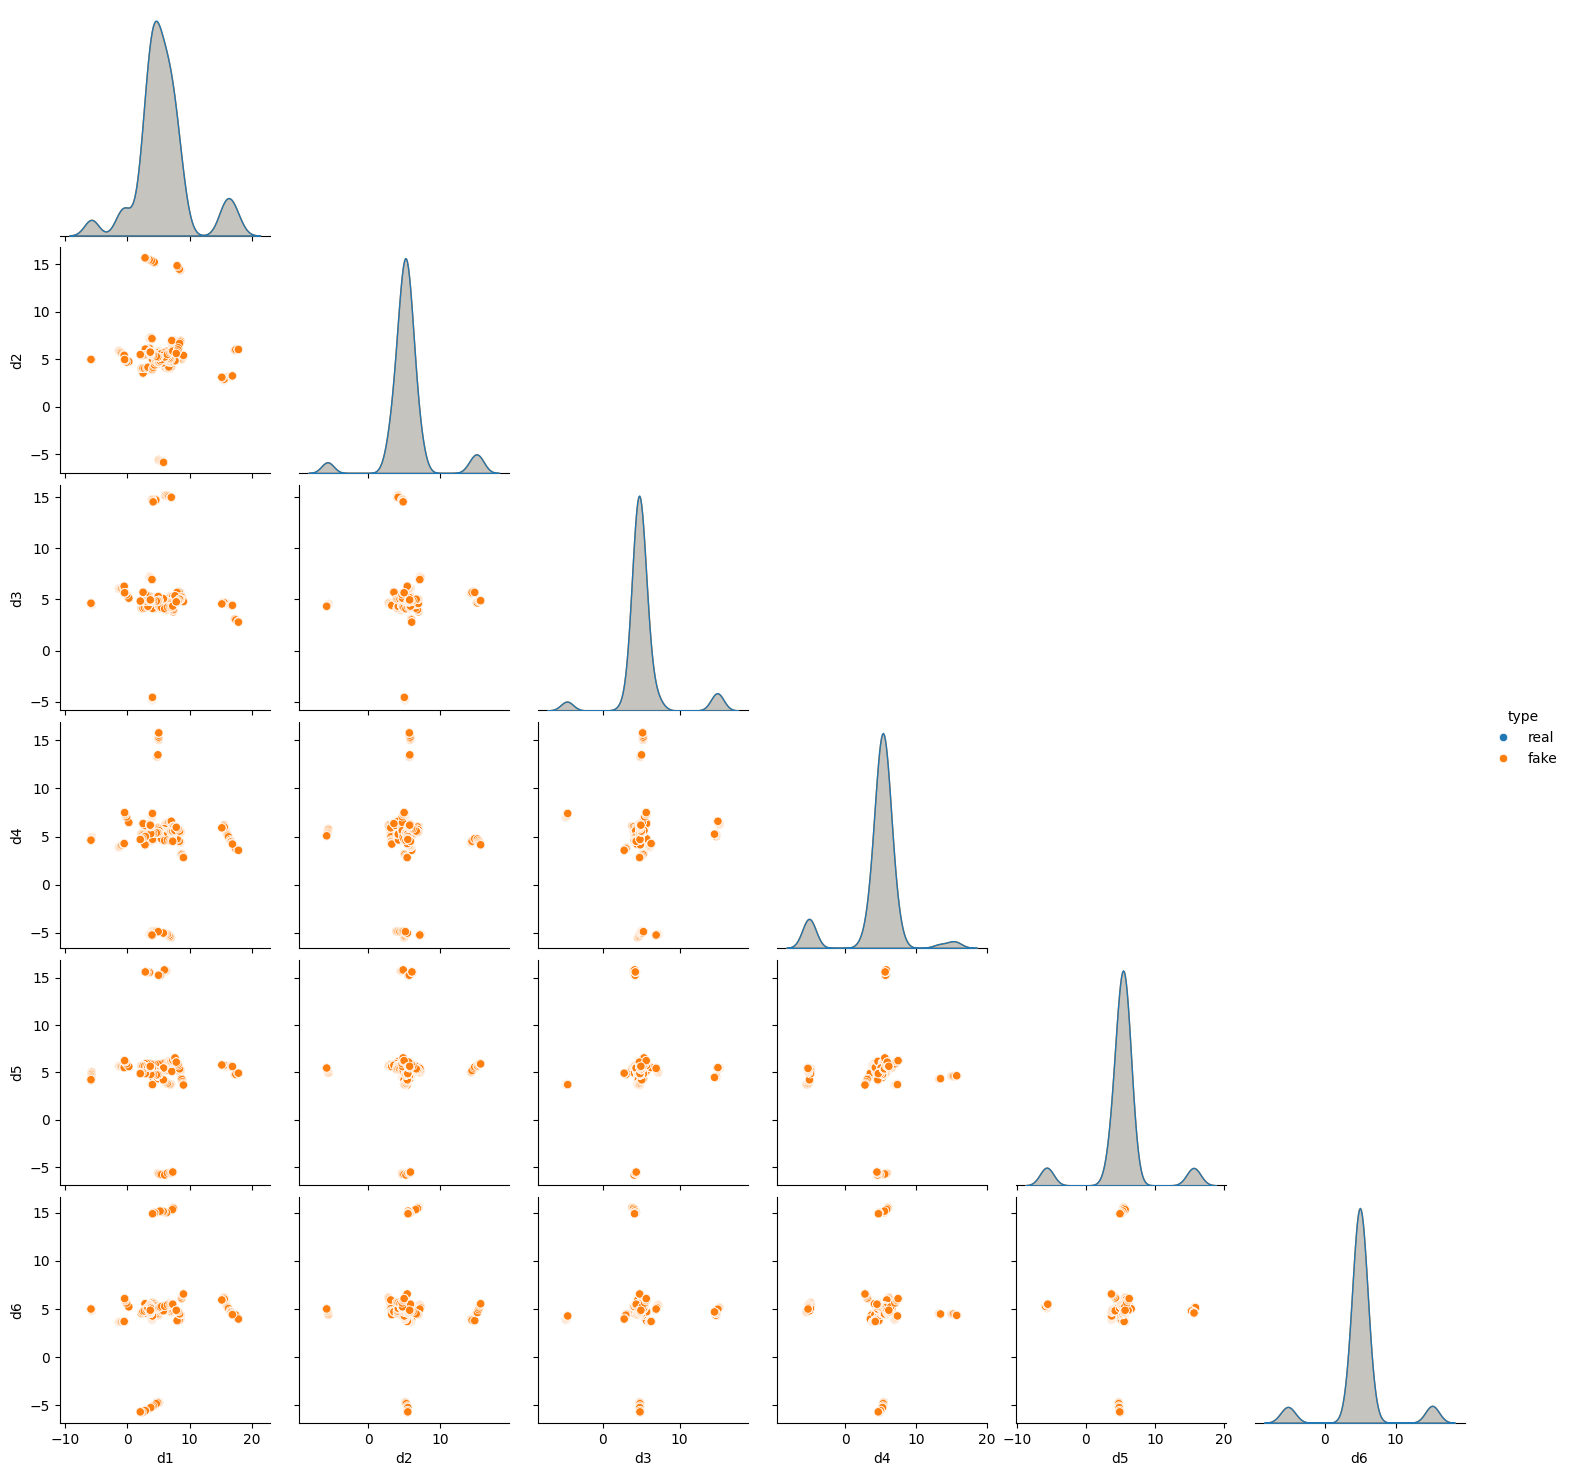

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

pair_cols = [f"d{i+1}" for i in range(6)]

sns.pairplot(df_umap[pair_cols + ["type"]], hue="type", corner=True)
plt.show()

In [18]:
import os
from itertools import combinations
import matplotlib.pyplot as plt

out_dir = "D:/KLAUS/Vis_Final_Project/umap_pairwise_16d"
os.makedirs(out_dir, exist_ok=True)

pairs = list(combinations(umap_cols, 2))

for c1, c2 in pairs:
    plt.figure(figsize=(6, 5))
    
    for label in ["real", "fake"]:
        idx = df_umap["type"] == label
        plt.scatter(
            df_umap.loc[idx, c1],
            df_umap.loc[idx, c2],
            label=label,
            alpha=0.5,
            s=12
        )
    
    plt.xlabel(c1)
    plt.ylabel(c2)
    plt.title(f"UMAP Pairwise: {c1} vs {c2}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{c1}_vs_{c2}.png"), dpi=200)
    plt.close()

print("Saved all pairwise plots to:", out_dir)

Saved all pairwise plots to: D:/KLAUS/Vis_Final_Project/umap_pairwise_16d


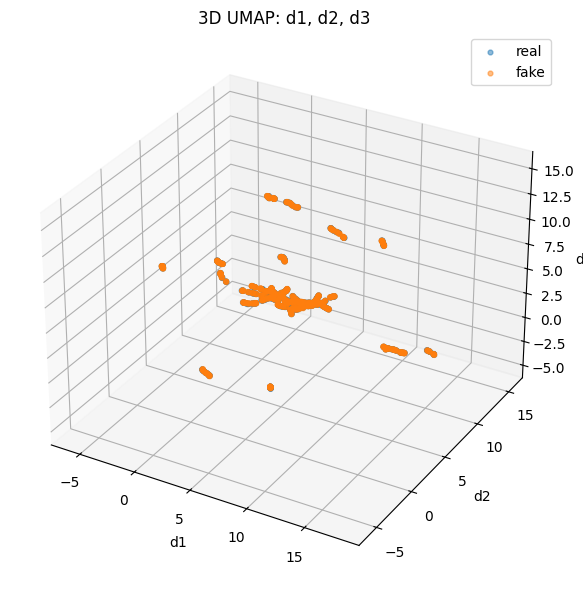

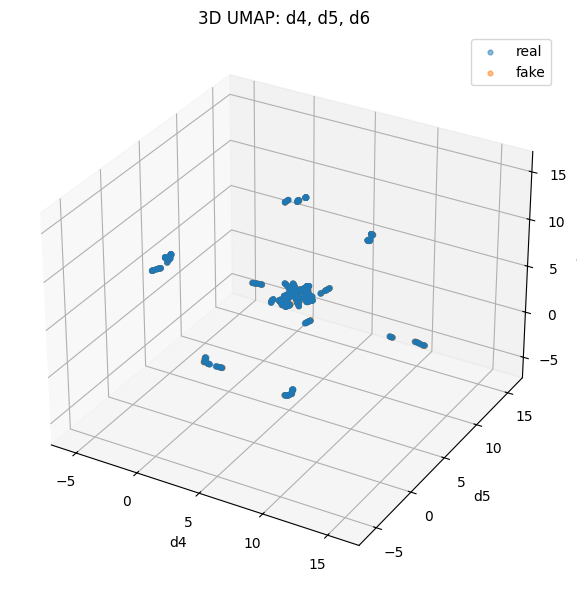

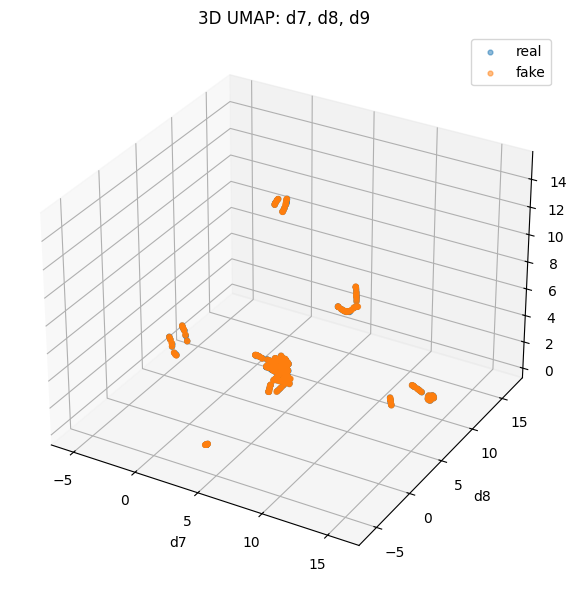

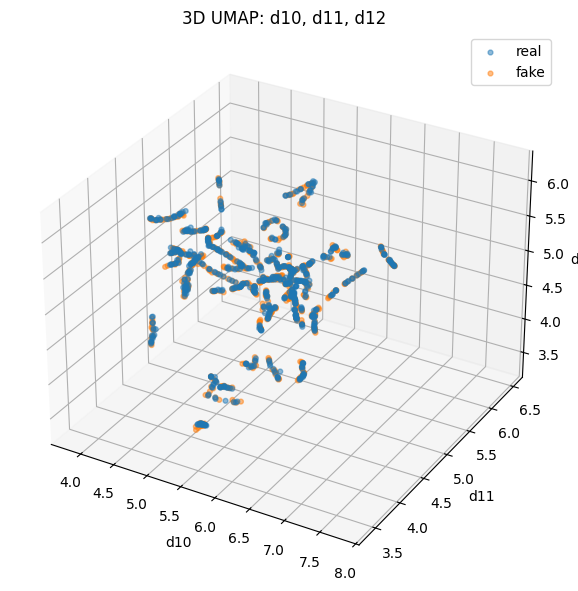

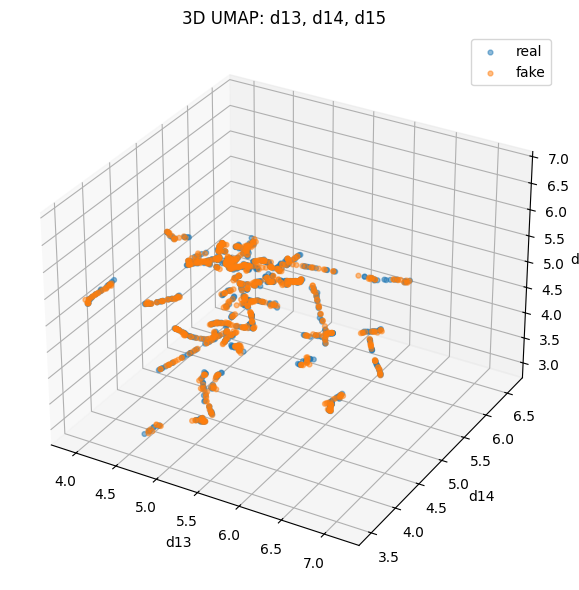

In [19]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

triples = [
    ("d1", "d2", "d3"),
    ("d4", "d5", "d6"),
    ("d7", "d8", "d9"),
    ("d10", "d11", "d12"),
    ("d13", "d14", "d15"),
]

for xcol, ycol, zcol in triples:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    for label in ["real", "fake"]:
        idx = df_umap["type"] == label
        ax.scatter(
            df_umap.loc[idx, xcol],
            df_umap.loc[idx, ycol],
            df_umap.loc[idx, zcol],
            label=label,
            alpha=0.5,
            s=12
        )

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_zlabel(zcol)
    ax.set_title(f"3D UMAP: {xcol}, {ycol}, {zcol}")
    ax.legend()
    plt.tight_layout()
    plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_10736\3849083667.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  real["type"] = "real"
C:\Users\hp\AppData\Local\Temp\ipykernel_10736\3849083667.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fake["type"] = "fake"
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


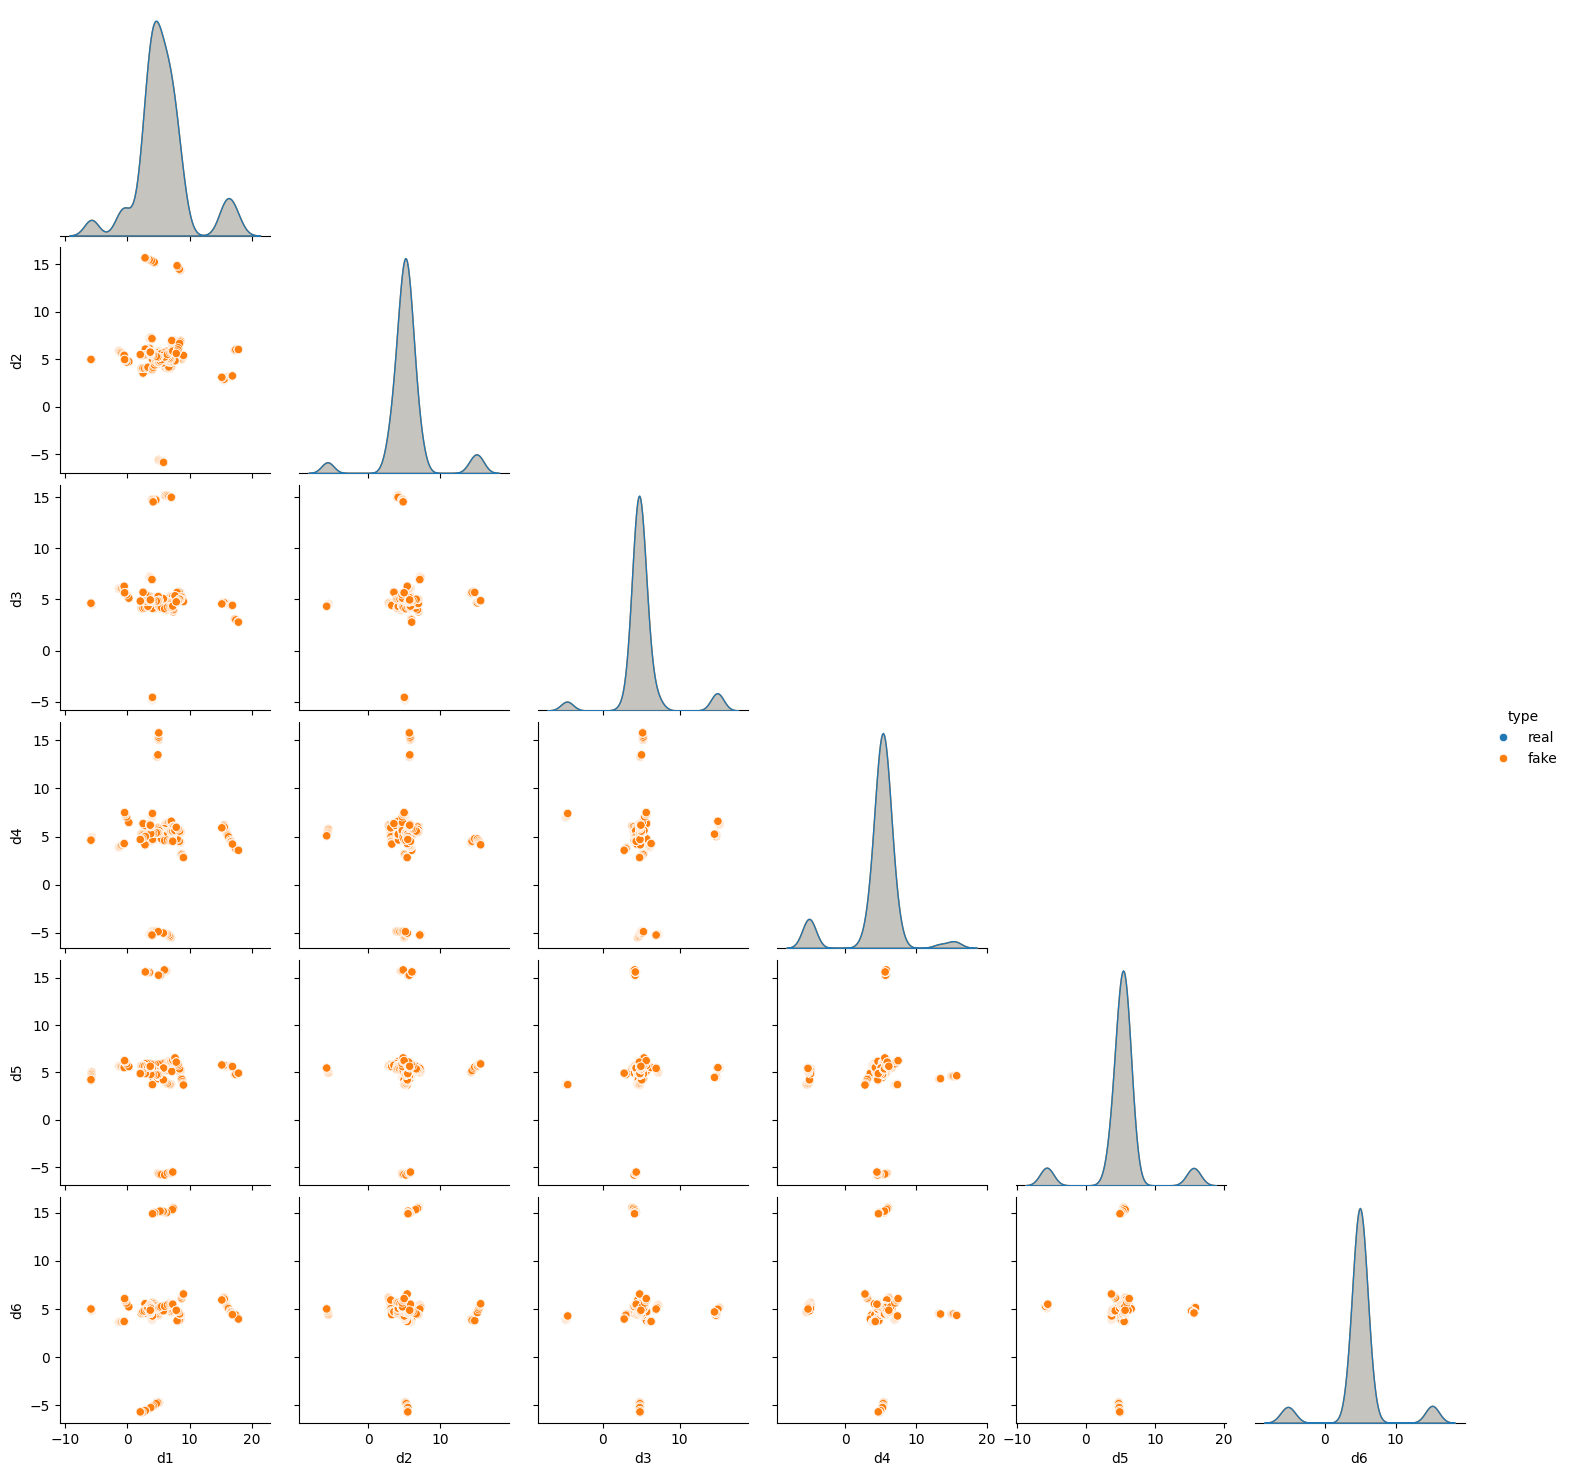

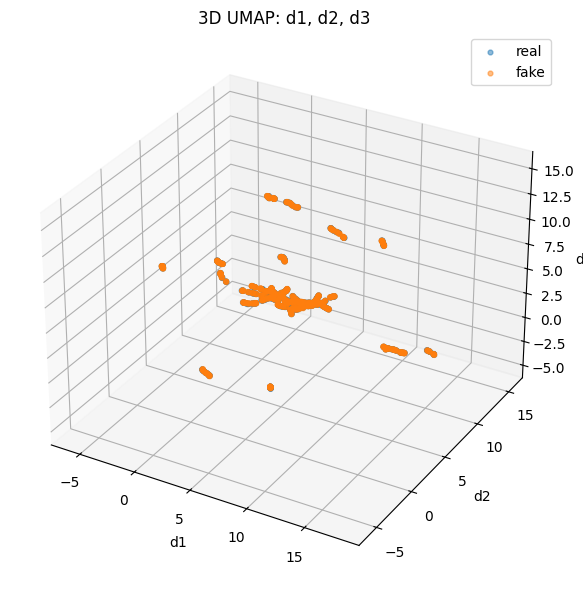

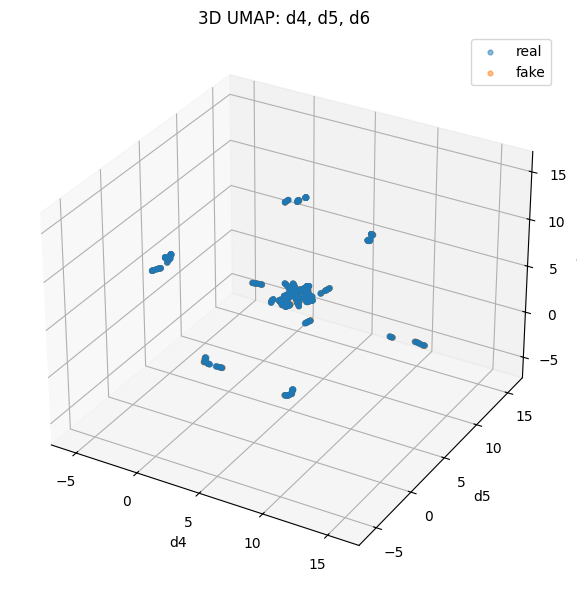

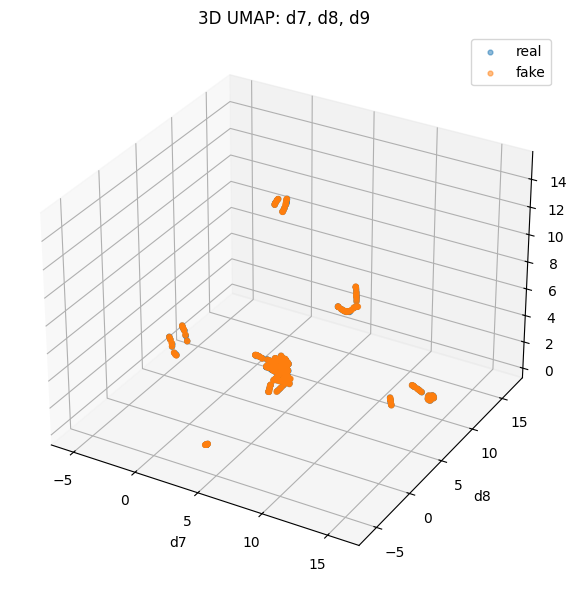

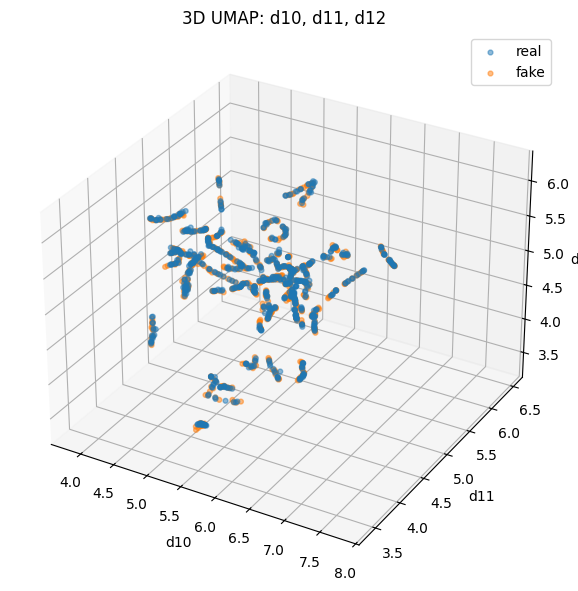

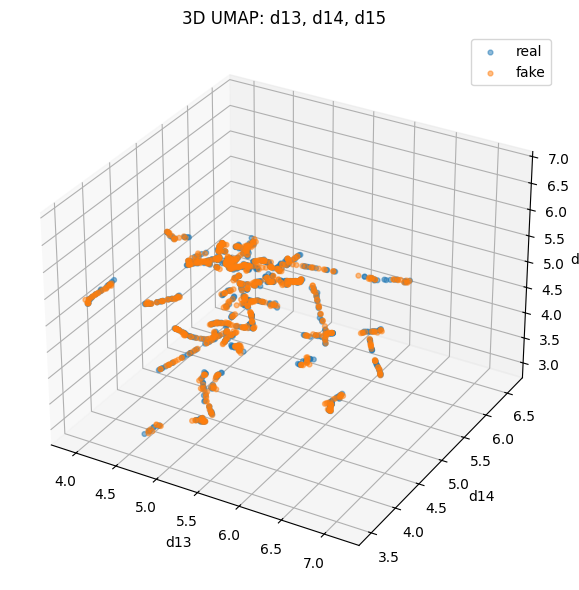

In [20]:
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from itertools import combinations
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Load data
# -----------------------------
real = pd.read_csv("D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv")
fake = pd.read_csv("D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv")

real["type"] = "real"
fake["type"] = "fake"

df = pd.concat([real, fake], ignore_index=True)

# keep only actual feature columns
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

X = df[feature_cols].values
y = df["type"].values

# -----------------------------
# 16D UMAP
# -----------------------------
reducer = umap.UMAP(
    n_components=16,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
X_umap = reducer.fit_transform(X)

umap_cols = [f"d{i+1}" for i in range(16)]
df_umap = pd.DataFrame(X_umap, columns=umap_cols)
df_umap["type"] = y

# -----------------------------
# Pairplot for first 6 dims
# -----------------------------
pair_cols = [f"d{i+1}" for i in range(6)]
sns.pairplot(df_umap[pair_cols + ["type"]], hue="type", corner=True)
plt.show()

# -----------------------------
# 3D grouped plots
# -----------------------------
triples = [
    ("d1", "d2", "d3"),
    ("d4", "d5", "d6"),
    ("d7", "d8", "d9"),
    ("d10", "d11", "d12"),
    ("d13", "d14", "d15"),
]

for xcol, ycol, zcol in triples:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    for label in ["real", "fake"]:
        idx = df_umap["type"] == label
        ax.scatter(
            df_umap.loc[idx, xcol],
            df_umap.loc[idx, ycol],
            df_umap.loc[idx, zcol],
            label=label,
            alpha=0.5,
            s=12
        )

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_zlabel(zcol)
    ax.set_title(f"3D UMAP: {xcol}, {ycol}, {zcol}")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [29]:
from sklearn.cluster import DBSCAN
import numpy as np

# use UMAP embedding
X_embed = X_umap[:, :2]   # or use full 16D if you want

# cluster
db = DBSCAN(eps=0.8, min_samples=10).fit(X_embed)
labels = db.labels_

df_umap["cluster"] = labels

# analyze clusters
clusters = np.unique(labels)

for c in clusters:
    if c == -1:
        continue  # skip noise

    idx = df_umap["cluster"] == c
    total = np.sum(idx)
    
    real_count = np.sum((df_umap["type"] == "real") & idx)
    fake_count = np.sum((df_umap["type"] == "fake") & idx)
    
    print(f"Cluster {c}: total={total}, real={real_count}, fake={fake_count}, fake_ratio={fake_count/total:.2f}")

Cluster 0: total=112, real=56, fake=56, fake_ratio=0.50
Cluster 1: total=32, real=16, fake=16, fake_ratio=0.50
Cluster 2: total=40, real=20, fake=20, fake_ratio=0.50
Cluster 3: total=56, real=28, fake=28, fake_ratio=0.50
Cluster 4: total=1072, real=536, fake=536, fake_ratio=0.50
Cluster 5: total=88, real=44, fake=44, fake_ratio=0.50
Cluster 6: total=40, real=20, fake=20, fake_ratio=0.50
Cluster 7: total=48, real=24, fake=24, fake_ratio=0.50
Cluster 8: total=48, real=24, fake=24, fake_ratio=0.50
Cluster 9: total=48, real=24, fake=24, fake_ratio=0.50


In [30]:
from sklearn.neighbors import KernelDensity

# fit KDE
kde_real = KernelDensity(bandwidth=0.5).fit(X_umap[y == "real"])
kde_fake = KernelDensity(bandwidth=0.5).fit(X_umap[y == "fake"])

# compute density ratio
log_real = kde_real.score_samples(X_umap)
log_fake = kde_fake.score_samples(X_umap)

density_ratio = np.exp(log_fake - log_real)

df_umap["density_ratio"] = density_ratio

In [31]:
# pick a region (example: high d1 values)
region_idx = df_umap["d1"] > df_umap["d1"].quantile(0.8)

real_region = df[region_idx & (df["type"] == "real")]
fake_region = df[region_idx & (df["type"] == "fake")]

# compare features
diff = (fake_region[feature_cols].mean() - real_region[feature_cols].mean()).abs()

# top differing features
top_features = diff.sort_values(ascending=False).head(10)
print(top_features)

f076    0.038923
f063    0.032757
f126    0.025627
f061    0.023579
f053    0.021634
f118    0.021193
f086    0.020881
f044    0.020733
f119    0.020552
f022    0.020179
dtype: float64
